<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part IV · Preparing Data &nbsp;|&nbsp; Chapter 25</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Exploratory Data Analysis <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos that walk the EDA workflow on one dataset: the first-contact audit, a variable on its own, two variables together, the whole correlation matrix at once, and why linear correlation can hide a perfect relationship.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | First contact | shape, info, describe, missing, duplicates |
| 2 | Univariate | one variable: center, spread, shape, counts |
| 3 | Bivariate | two variables: scatter + r, groups + box plots |
| 4 | The correlation heatmap | every pair at once; spot multicollinearity |
| 5 | Pearson vs Spearman | linear-only correlation can miss a perfect curve |

> EDA is detective work (Tukey): look first, let the data reveal its structure, then form the questions worth testing.

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_iris

rng = np.random.default_rng(25)
NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12.5,"axes.titleweight":"bold","axes.titlecolor":INK,"legend.frameon":False})

iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={c: c.replace(" (cm)","").replace(" ","_") for c in iris.frame.columns})
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)
feat = ["sepal_length","sepal_width","petal_length","petal_width"]
print("✅ Loaded iris:", df.shape)

✅ Loaded iris: (150, 6)


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · FIRST CONTACT</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔍 How big, what's in it, is it clean?</div>
<div style="color:#4a5578;margin-top:6px">Before any analysis, audit the dataset. shape and info tell you the size and the dtypes; describe summarizes the numbers; isna and duplicated check quality. This is the Part IV cleaning pass in one screen.</div>
</div>

In [2]:
print("shape:", df.shape)
print("\n-- dtypes & non-null counts --"); df.info()
print("\n-- numeric summary --"); print(df[feat].describe().round(2))
print("\nmissing per column:", df.isna().sum().sum(), " | duplicate rows:", df.duplicated().sum())
print("species balance:"); print(df["species"].value_counts().to_string())

shape: (150, 6)

-- dtypes & non-null counts --
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sepal_length  150 non-null    float64 
 1   sepal_width   150 non-null    float64 
 2   petal_length  150 non-null    float64 
 3   petal_width   150 non-null    float64 
 4   target        150 non-null    int64   
 5   species       150 non-null    category
dtypes: category(1), float64(4), int64(1)
memory usage: 6.2 KB

-- numeric summary --
       sepal_length  sepal_width  petal_length  petal_width
count        150.00       150.00        150.00       150.00
mean           5.84         3.06          3.76         1.20
std            0.83         0.44          1.77         0.76
min            4.30         2.00          1.00         0.10
25%            5.10         2.80          1.60         0.30
50%            5.80         3.00          4.35         1.30
7

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · UNIVARIATE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📊 One variable at a time</div>
<div style="color:#4a5578;margin-top:6px">For a numeric variable, ask four questions: center, spread, shape, and outliers, with a histogram and a box plot. For a categorical variable, count the levels. Here is petal_length and the species counts.</div>
</div>

center : mean 3.76, median 4.35
spread : SD 1.77, IQR 3.50
shape  : skew -0.27, excess kurtosis -1.40


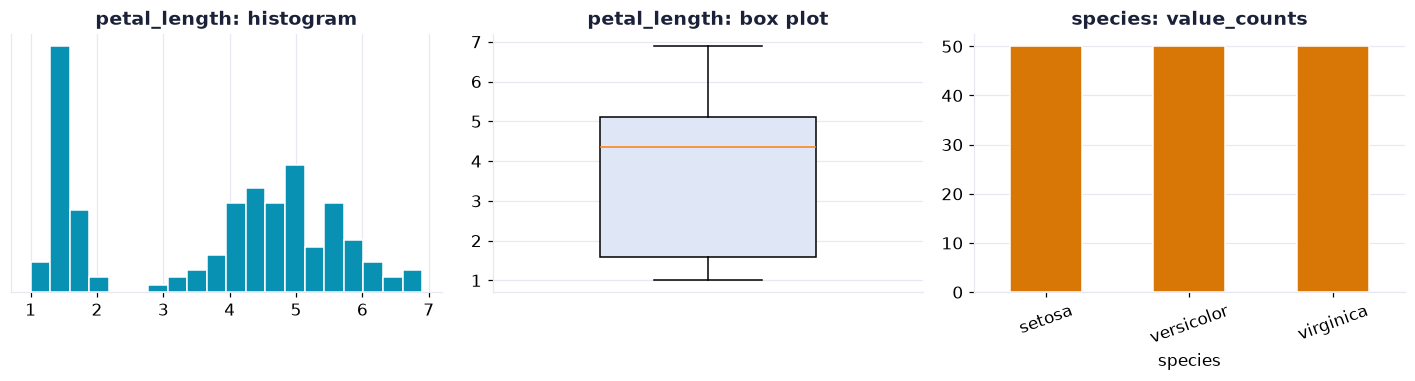

The histogram is clearly bimodal: a hint that species are mixed together (we explore that next).


In [3]:
x = df["petal_length"]
print(f"center : mean {x.mean():.2f}, median {x.median():.2f}")
print(f"spread : SD {x.std():.2f}, IQR {x.quantile(.75)-x.quantile(.25):.2f}")
print(f"shape  : skew {x.skew():+.2f}, excess kurtosis {x.kurt():+.2f}")

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(13, 3.6))
a1.hist(x, bins=20, color=CYAN, edgecolor="white"); a1.set_title("petal_length: histogram"); a1.set_yticks([])
a2.boxplot(x, widths=0.5, patch_artist=True, boxprops=dict(facecolor="#dfe7f7"))
a2.set_title("petal_length: box plot"); a2.set_xticks([])
df["species"].value_counts().plot.bar(ax=a3, color=AMBER, edgecolor="white")
a3.set_title("species: value_counts"); a3.tick_params(axis="x", rotation=20); a3.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
print("The histogram is clearly bimodal: a hint that species are mixed together (we explore that next).")

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · BIVARIATE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔗 Two variables together</div>
<div style="color:#4a5578;margin-top:6px">Now ask how variables relate. Numeric vs numeric: a scatter plus a correlation. Categorical vs numeric: compare the distributions across groups with side-by-side box plots and group means. The bimodal petal length resolves into clean species.</div>
</div>

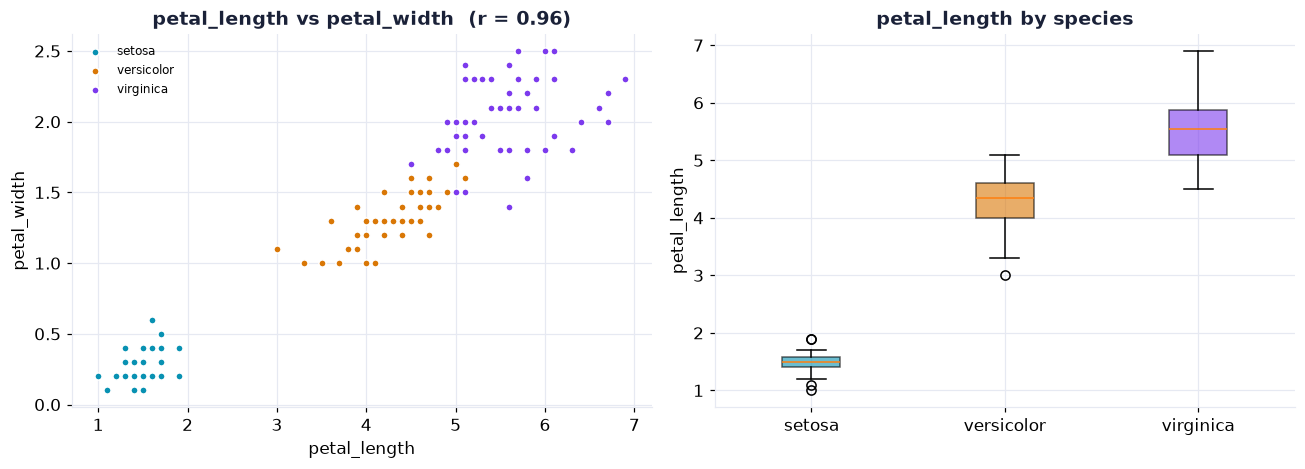

group means (petal_length):
species
setosa        1.46
versicolor    4.26
virginica     5.55


In [4]:
x, y = df["petal_length"], df["petal_width"]
r = np.corrcoef(x, y)[0, 1]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
cmap = {"setosa":CYAN, "versicolor":AMBER, "virginica":PURPLE}
for sp, c in cmap.items():
    sub = df[df["species"] == sp]
    a1.scatter(sub["petal_length"], sub["petal_width"], color=c, s=22, edgecolor="white", label=sp)
a1.set_title(f"petal_length vs petal_width  (r = {r:.2f})"); a1.set_xlabel("petal_length"); a1.set_ylabel("petal_width"); a1.legend(fontsize=8)

groups = [df.loc[df["species"]==s, "petal_length"].values for s in cmap]
bp = a2.boxplot(groups, patch_artist=True)
for patch, c in zip(bp["boxes"], cmap.values()): patch.set_facecolor(c); patch.set_alpha(0.6)
a2.set_xticks([1,2,3]); a2.set_xticklabels(list(cmap)); a2.set_title("petal_length by species"); a2.set_ylabel("petal_length")
plt.tight_layout(); plt.show()
print("group means (petal_length):"); print(df.groupby("species", observed=True)["petal_length"].mean().round(2).to_string())

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · THE CORRELATION HEATMAP</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔥 Every pair at once</div>
<div style="color:#4a5578;margin-top:6px">A correlation heatmap shows all pairwise relationships in one grid, on a diverging scale centered at 0 (Chapter 16). Blocks of high values flag MULTICOLLINEARITY, redundant features. Here petal_length and petal_width are almost perfectly correlated.</div>
</div>

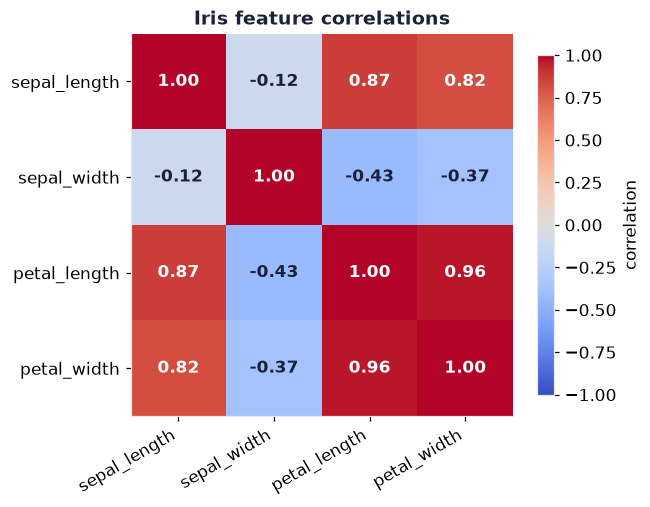

petal_length & petal_width ~0.96: nearly redundant. In modeling you might drop or combine one.
(sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0) is the seaborn one-liner.)


In [5]:
corr = df[feat].corr().values

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(feat, rotation=30, ha="right")
ax.set_yticks(range(4)); ax.set_yticklabels(feat); ax.grid(False)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr[i,j])>0.55 else INK, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
ax.set_title("Iris feature correlations"); plt.tight_layout(); plt.show()
print("petal_length & petal_width ~0.96: nearly redundant. In modeling you might drop or combine one.")
print("(sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0) is the seaborn one-liner.)")

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · PEARSON VS SPEARMAN</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🧮 Correlation captures LINEAR only</div>
<div style="color:#4a5578;margin-top:6px">A heatmap (and Pearson r) measures LINEAR association, so a perfect but curved relationship can show a deflated r (remember Anscombe). Spearman correlates the RANKS, so it captures any monotonic relationship, and resists outliers.</div>
</div>

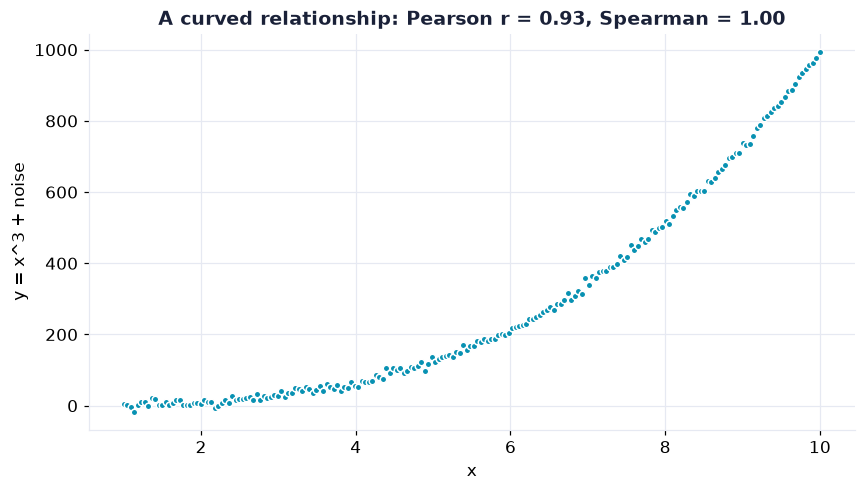

Pearson  (linear)   = 0.935   <- below 1, the curve is not a straight line
Spearman (monotonic) = 0.996  <- near 1, it sees the perfect ranking
Always plot the data; a single coefficient never tells the whole story.


In [6]:
x = np.linspace(1, 10, 200)
y = x**3 + rng.normal(0, 8, 200)        # a perfect monotonic curve, plus noise
pearson  = stats.pearsonr(x, y)[0]
spearman = stats.spearmanr(x, y)[0]

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(x, y, color=CYAN, s=18, edgecolor="white")
ax.set_title(f"A curved relationship: Pearson r = {pearson:.2f}, Spearman = {spearman:.2f}")
ax.set_xlabel("x"); ax.set_ylabel("y = x^3 + noise")
plt.tight_layout(); plt.show()
print(f"Pearson  (linear)   = {pearson:.3f}   <- below 1, the curve is not a straight line")
print(f"Spearman (monotonic) = {spearman:.3f}  <- near 1, it sees the perfect ranking")
print("Always plot the data; a single coefficient never tells the whole story.")

## 🔍 Real-World Example: Exploring a Churn Dataset
The whole EDA workflow on one table: **profile** it (shape, types, missing), **describe** the distributions, and **compare the target across groups**. In a few lines the story appears, overall churn is about 22%, it is highest on the Basic plan, and churners have noticeably shorter tenure. This is the understanding you build *before* fitting any model.

shape (500, 7)   missing values: 0
overall churn rate: 21.6%
churn rate by plan:
plan
Basic       27.2%
Premium     15.8%
Standard    17.1%
Name: churned, dtype: str

correlation of each numeric feature with churn: {'age': 0.04, 'tenure_months': -0.16, 'monthly_spend': -0.1, 'support_tickets': 0.08}


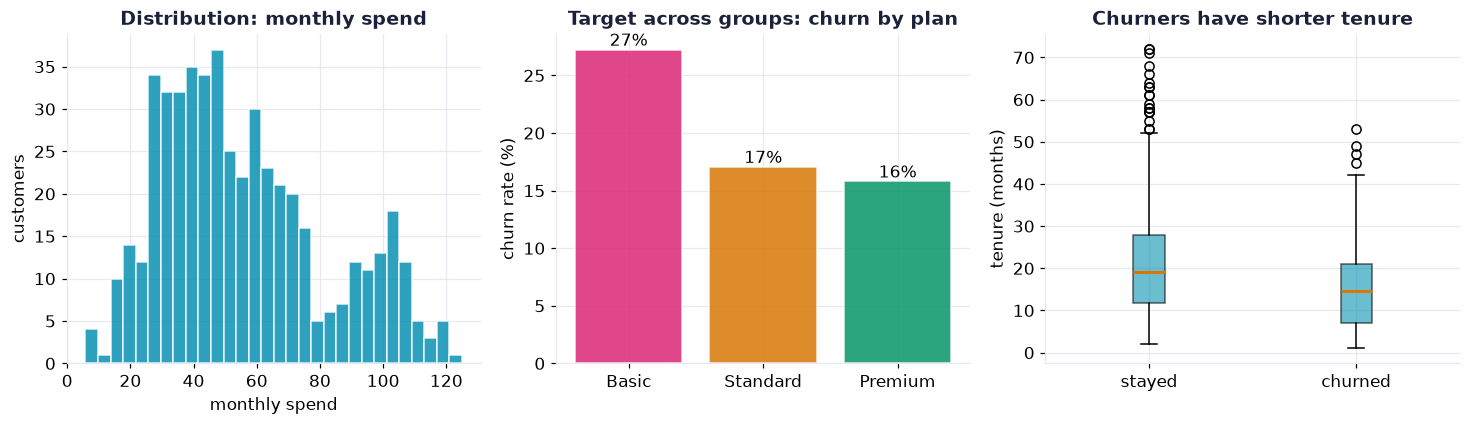

In [7]:
# --- Real-World beat: a full exploratory pass on a churn table ---
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    cust = pd.read_excel("../../data/exploratory-data-analysis-eda--customer_analytics.xlsx", sheet_name="Data")
except FileNotFoundError: cust = pd.read_excel(BASE+"exploratory-data-analysis-eda--customer_analytics.xlsx", sheet_name="Data")
print(f"shape {cust.shape}   missing values: {int(cust.isna().sum().sum())}")
print(f"overall churn rate: {cust.churned.mean():.1%}")
print("churn rate by plan:"); print((cust.groupby('plan').churned.mean()*100).round(1).astype(str) + '%')
num = ["age","tenure_months","monthly_spend","support_tickets"]
print("\ncorrelation of each numeric feature with churn:", cust[num+['churned']].corr()['churned'].drop('churned').round(2).to_dict())
fig, ax = plt.subplots(1, 3, figsize=(13.5,4))
ax[0].hist(cust.monthly_spend, bins=30, color=CYAN, alpha=0.85, edgecolor="white")
ax[0].set_title("Distribution: monthly spend"); ax[0].set_xlabel("monthly spend"); ax[0].set_ylabel("customers")
cr = cust.groupby("plan").churned.mean().reindex(["Basic","Standard","Premium"])*100
bars = ax[1].bar(cr.index, cr.values, color=[PINK, AMBER, GREEN], alpha=0.85, edgecolor="white")
ax[1].bar_label(bars, fmt="%.0f%%"); ax[1].set_title("Target across groups: churn by plan"); ax[1].set_ylabel("churn rate (%)")
ax[2].boxplot([cust[cust.churned==0].tenure_months, cust[cust.churned==1].tenure_months],
              patch_artist=True, boxprops=dict(facecolor=CYAN, alpha=0.6), medianprops=dict(color=AMBER, linewidth=2))
ax[2].set_xticklabels(["stayed", "churned"]); ax[2].set_title("Churners have shorter tenure"); ax[2].set_ylabel("tenure (months)")
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>First contact</b>: shape, info, describe, missing, duplicates, the audit before any analysis.</li>
<li><b>Univariate</b>: one variable's center, spread, shape, outliers (numeric) or counts (categorical).</li>
<li><b>Bivariate</b>: scatter + correlation for num-num; grouped box plots and group means for cat-num.</li>
<li>The <b>correlation heatmap</b> shows every pair at once and flags multicollinearity (redundant features).</li>
<li>Correlation is <b>linear only</b>: Spearman (on ranks) catches monotonic curves; always plot the data.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>